In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, roc_auc_score,
    precision_recall_curve, roc_curve
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt



import warnings
warnings.filterwarnings('ignore')

# constants
#RSEED = 10

1. Data Import

In [21]:
# import data from CSV
df = pd.read_csv("data/kickstarter_projects.csv")

In [22]:

# check import
df.head()

,ID,Name,Category,Subcategory,Country,Launched,Deadline,Goal,Pledged,Backers,State
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed


In [23]:
df.columns

Index(['ID', 'Name', 'Category', 'Subcategory', 'Country', 'Launched',
       'Deadline', 'Goal', 'Pledged', 'Backers', 'State'],
      dtype='object')

In [24]:
# 11 Columns:
# id
# name	
# category	
# subcategory	
# country	
# launched	
# deadline	
# goal	
# pledged	
# backers	
# state
df.columns = df.columns.str.lower()
df.head()

,id,name,category,subcategory,country,launched,deadline,goal,pledged,backers,state
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed


1.1 Data Check

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374853 entries, 0 to 374852
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           374853 non-null  int64 
 1   name         374853 non-null  object
 2   category     374853 non-null  object
 3   subcategory  374853 non-null  object
 4   country      374853 non-null  object
 5   launched     374853 non-null  object
 6   deadline     374853 non-null  object
 7   goal         374853 non-null  int64 
 8   pledged      374853 non-null  int64 
 9   backers      374853 non-null  int64 
 10  state        374853 non-null  object
dtypes: int64(4), object(7)
memory usage: 31.5+ MB


1.2 Statistcal Summary Check

In [26]:
df.describe()

,id,goal,pledged,backers
count,3.748530e+05,3.748530e+05,3.748530e+05,374853.000000
mean,1.074656e+09,4.586378e+04,9.121073e+03,106.690359
std,6.191377e+08,1.158778e+06,9.132054e+04,911.718520
min,5.971000e+03,0.000000e+00,0.000000e+00,0.000000
25%,5.380728e+08,2.000000e+03,3.100000e+01,2.000000
50%,1.075300e+09,5.500000e+03,6.250000e+02,12.000000
75%,1.610149e+09,1.600000e+04,4.051000e+03,57.000000
max,2.147476e+09,1.663614e+08,2.033899e+07,219382.000000


2 EDA
General Feature Exploration

In [27]:
# 2) Quick look
print("Shape:", df.shape)
display(df.head())
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum().sort_values(ascending=False))
# Rows 378661, 
# columns 11
# it shows the data types and missing values for each column. we have object and int64 data types.

Shape: (374853, 11)


,id,name,category,subcategory,country,launched,deadline,goal,pledged,backers,state
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed



Dtypes:
 id              int64
name           object
category       object
subcategory    object
country        object
launched       object
deadline       object
goal            int64
pledged         int64
backers         int64
state          object
dtype: object

Missing values:
 id             0
name           0
category       0
subcategory    0
country        0
launched       0
deadline       0
goal           0
pledged        0
backers        0
state          0
dtype: int64


In [28]:
df['state'].value_counts()

state
Failed        197611
Successful    133851
Canceled       38751
Live            2798
Suspended       1842
Name: count, dtype: int64

In [29]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374853 entries, 0 to 374852
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           374853 non-null  int64 
 1   name         374853 non-null  object
 2   category     374853 non-null  object
 3   subcategory  374853 non-null  object
 4   country      374853 non-null  object
 5   launched     374853 non-null  object
 6   deadline     374853 non-null  object
 7   goal         374853 non-null  int64 
 8   pledged      374853 non-null  int64 
 9   backers      374853 non-null  int64 
 10  state        374853 non-null  object
dtypes: int64(4), object(7)
memory usage: 31.5+ MB


# Data cleaning and feature engineering

In [30]:
# 3) Parse dates + feature engineering
df["launched"] = pd.to_datetime(df["launched"], errors="coerce")
df["deadline"] = pd.to_datetime(df["deadline"], errors="coerce")

df["duration_days"] = (df["deadline"] - df["launched"]).dt.total_seconds() / (24 * 3600)
df["funded_ratio"] = df["pledged"] / df["goal"]
df["is_success"] = (df["state"].astype(str).str.lower() == "successful").astype(int)
display(df[["goal", "pledged", "backers", "duration_days", "funded_ratio"]].describe())

,goal,pledged,backers,duration_days,funded_ratio
count,3.748530e+05,3.748530e+05,374853.000000,374853.000000,3.748510e+05
mean,4.586378e+04,9.121073e+03,106.690359,33.651440,inf
std,1.158778e+06,9.132054e+04,911.718520,12.814719,NaN
min,0.000000e+00,0.000000e+00,0.000000,0.005058,0.000000e+00
25%,2.000000e+03,3.100000e+01,2.000000,29.098044,4.566438e-03
50%,5.500000e+03,6.250000e+02,12.000000,29.690787,1.342857e-01
75%,1.600000e+04,4.051000e+03,57.000000,36.740370,1.065250e+00
max,1.663614e+08,2.033899e+07,219382.000000,91.962650,inf


In [31]:
# 4) Feature engineering (best “value add” features)
df["duration_days"]    = (df["deadline"] - df["launched"]).dt.total_seconds() / (24 * 3600)
df["launch_year"]      = df["launched"].dt.year
df["launch_month"]     = df["launched"].dt.month
df["launch_dayofweek"] = df["launched"].dt.dayofweek

df["funded_ratio"]     = df["pledged"] / df["goal"].replace(0, np.nan)
df["funded_ratio"]     = df["funded_ratio"].replace([np.inf, -np.inf], np.nan).fillna(0)

df["log_goal"]         = np.log1p(df["goal"])
df["log_pledged"]      = np.log1p(df["pledged"])
df["log_backers"]      = np.log1p(df["backers"])        
df["name_length"]      = df["name"].astype(str).str.len()
df["name_word_count"]  = df["name"].astype(str).str.split().apply(len)

# Target (for EDA + modeling)
df["is_success"] = (df["state"].astype(str).str.lower() == "successful").astype(int)

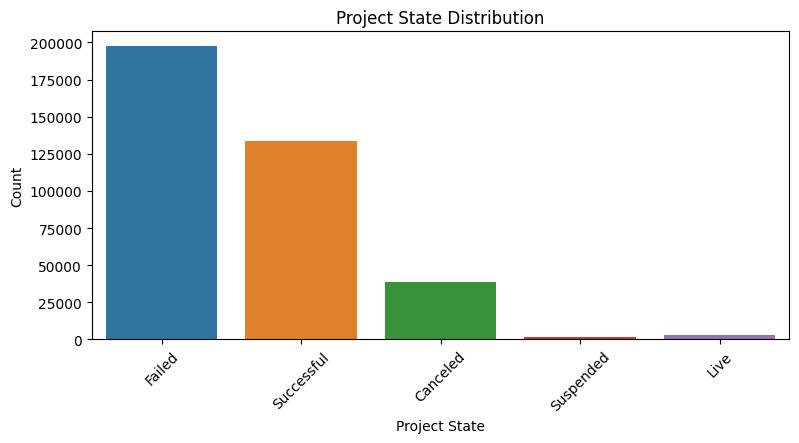

In [32]:
# A) Plotting the Project State Distribution
plt.subplots(figsize=(9,4), dpi=100)

sns.countplot(x="state",data=df)
plt.title("Project State Distribution")
plt.xlabel("Project State")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [33]:
# Quick look

success_projects = df[df['state'] == 'Successful']['state'].count()
fail_projects  = df[df['state'] == 'Failed']['state'].count()
others_projects  = (
    df[df['state'] == 'Canceled']['state'].count() +
    df[df['state'] == 'Live']['state'].count() +
    df[df['state'] == 'Suspended']['state'].count())

print(f"Successful Projects: {success_projects}")
print(f"Failed Projects: {fail_projects}")
print(f"Other Projects: {others_projects}")

Successful Projects: 133851
Failed Projects: 197611
Other Projects: 43391


In [34]:
total=success_projects+fail_projects+others_projects
suc=success_projects/total
fail=fail_projects/total
other=others_projects/total

Text(0.5, 1.0, 'Total Success Rate')

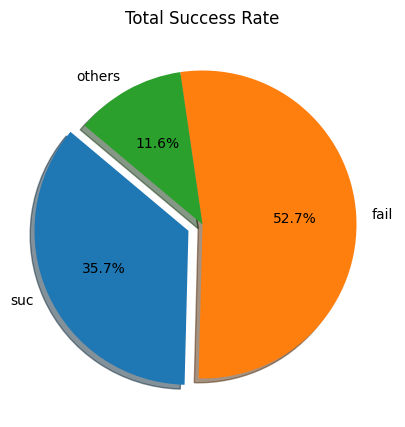

In [35]:
# B) Outcome distribution (Success vs Failed)
sizes = [suc, fail, other]
labels="suc","fail","others"
explode = (0.1, 0, 0)
plt.figure(figsize=(10,5), dpi=100)
plt.pie(sizes,labels=labels,explode=explode,
autopct='%1.1f%%', shadow=True, startangle=140)
plt.title("Total Success Rate")

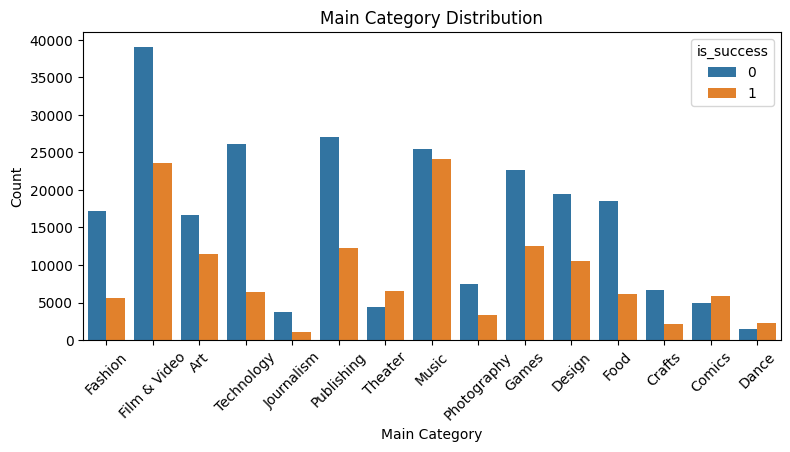

In [36]:
#Plotting the Main_category Distribution
plt.subplots(figsize=(9,4), dpi=100)
sns.countplot(x="category", hue="is_success", data=df)
plt.title("Main Category Distribution")
plt.xlabel("Main Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

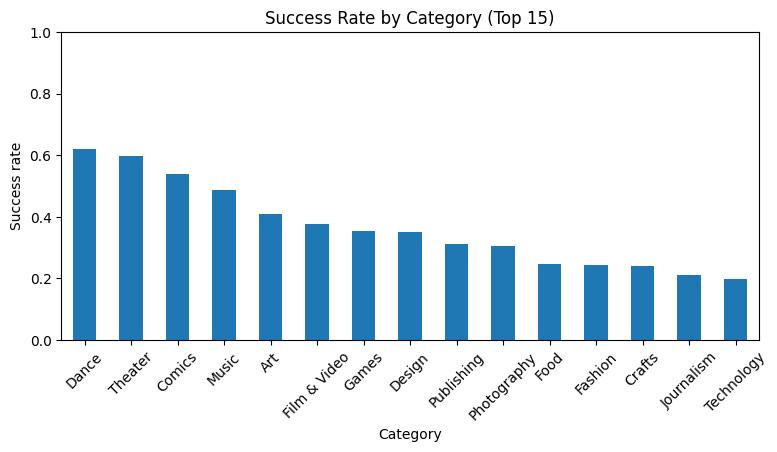

In [37]:
# C) Success rate by Category (Top 15 by volume)
top_cats = df["category"].value_counts().head(15).index
success_by_cat = (
    df[df["category"].isin(top_cats)]
    .groupby("category")["is_success"]
    .mean()
    .sort_values(ascending=False)
)
plt.figure(figsize=(9,4), dpi=100)
success_by_cat.plot(kind="bar")
plt.title("Success Rate by Category (Top 15)")
plt.xlabel("Category")
plt.ylabel("Success rate")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

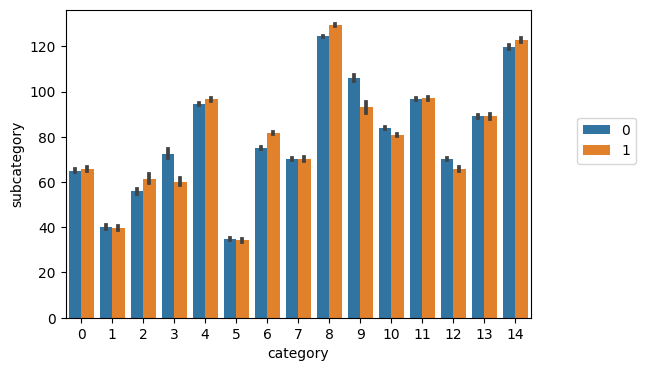

In [47]:
plt.figure(figsize=(6,4), dpi=100)
sns.barplot(data=df, x='category', y='subcategory', hue='is_success')
plt.legend(loc=(1.1,0.5))

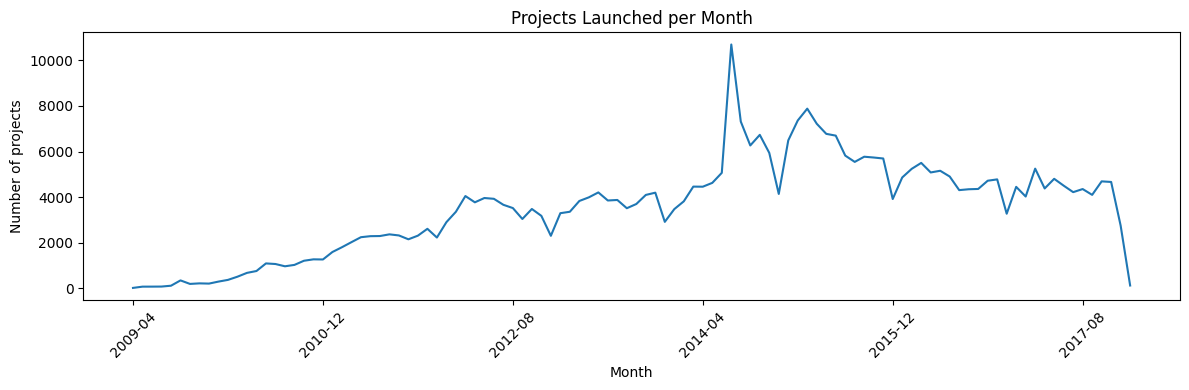

In [ ]:
# D) Projects launched over time (monthly)
df["launch_ym"] = df["launched"].dt.to_period("M").astype(str)
monthly_projects = df.dropna(subset=["launched"]).groupby("launch_ym").size()

plt.figure(figsize=(12,4))
monthly_projects.plot()
plt.title("Projects Launched per Month")
plt.xlabel("Month")
plt.ylabel("Number of projects")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

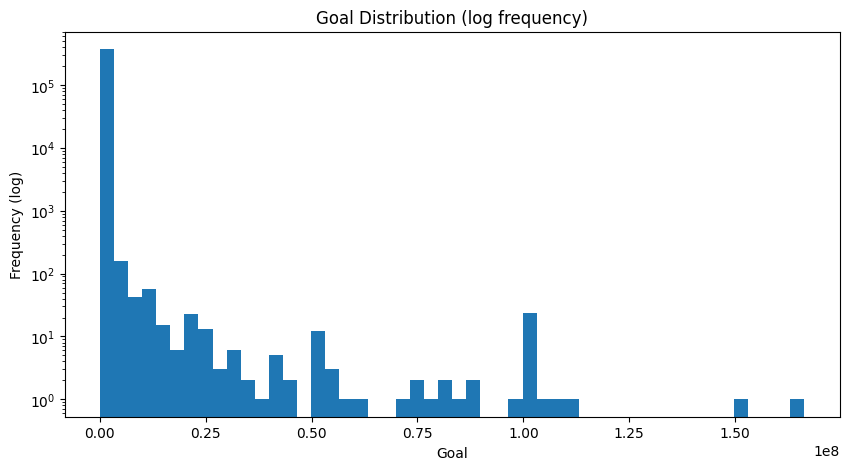

In [ ]:
# E) Goal distribution (log y-scale)
plt.figure(figsize=(10,5), dpi=100)
df["goal"].replace(0, np.nan).dropna().plot(kind="hist", bins=50, log=True)
plt.title("Goal Distribution (log frequency)")
plt.xlabel("Goal")
plt.ylabel("Frequency (log)")
plt.show()

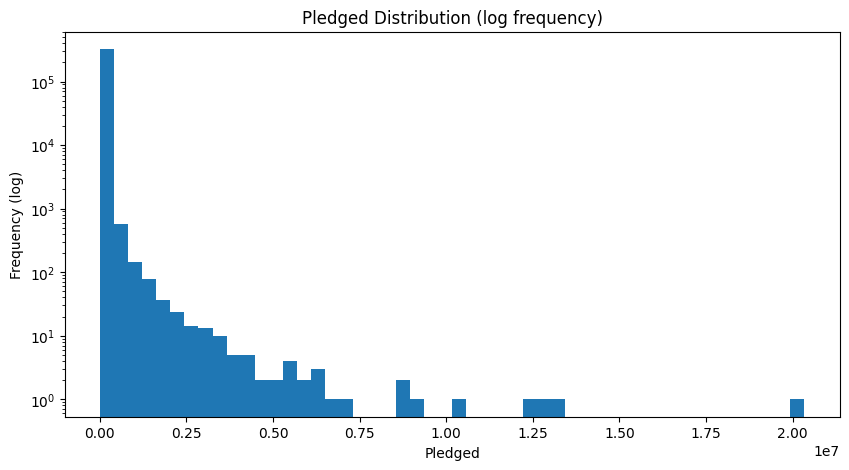

In [ ]:
# F) Pledged distribution (log y-scale)
plt.figure(figsize=(10,5), dpi=100)
df["pledged"].replace(0, np.nan).dropna().plot(kind="hist", bins=50, log=True)
plt.title("Pledged Distribution (log frequency)")
plt.xlabel("Pledged")
plt.ylabel("Frequency (log)")
plt.show()


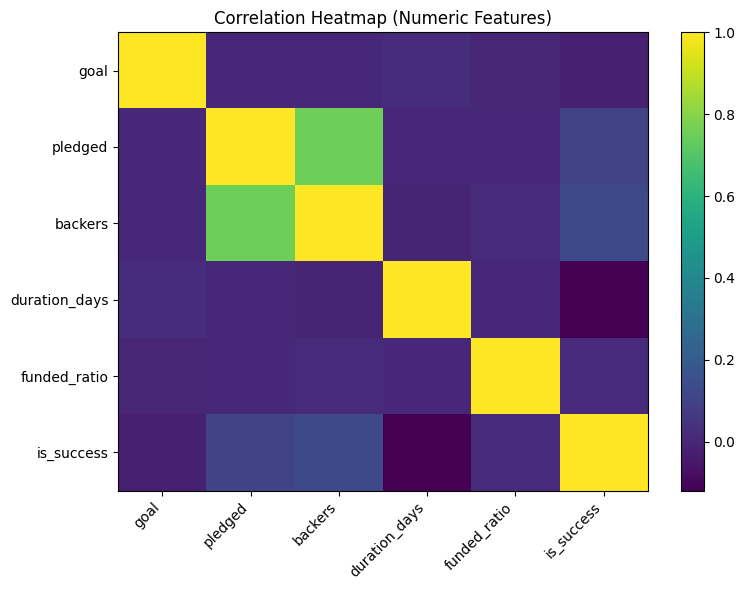

In [ ]:
# G) Correlation heatmap (numeric features)
num_cols = ["goal", "pledged", "backers", "duration_days", "funded_ratio", "is_success"]
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(8,6), dpi=100)
plt.imshow(corr, aspect="auto")
plt.title("Correlation Heatmap (Numeric Features)")
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
# (Optional) Final “model-ready” feature table preview
# -------------------------------------------------
feature_cols = [
    "category","subcategory","country",
    "duration_days","launch_year","launch_month","launch_dayofweek",
    "log_goal","log_pledged","log_backers",
    "funded_ratio","name_length","name_word_count",
    "is_success"
]
display(df[feature_cols].head())

,category,subcategory,country,duration_days,launch_year,launch_month,launch_dayofweek,log_goal,log_pledged,log_backers,funded_ratio,name_length,name_word_count,is_success
0,Fashion,Fashion,United States,39.123056,2009,4,1,6.908755,6.439350,3.433987,0.625000,59,10,0
1,Film & Video,Shorts,United States,87.994525,2009,4,3,11.289794,3.135494,1.386294,0.000275,30,4,0
2,Art,Illustration,United States,8.088854,2009,4,4,3.044522,3.583519,1.386294,1.750000,19,3,1
3,Technology,Software,United States,79.266424,2009,4,5,4.605170,4.983607,3.258097,1.464646,28,4,1
4,Fashion,Fashion,United States,28.409271,2009,4,0,7.550135,5.961005,2.397895,0.203684,10,1,0


In [42]:
# Drop unused fields
df = df.drop(columns=["id", "name", "launched", "deadline", "state"], axis=1)

In [ ]:
df.head()

,category,subcategory,country,goal,pledged,backers,duration_days,funded_ratio,is_success,launch_year,launch_month,launch_dayofweek,log_goal,log_pledged,log_backers,name_length,name_word_count,launch_ym
0,Fashion,Fashion,United States,1000,625,30,39.123056,0.625000,0,2009,4,1,6.908755,6.439350,3.433987,59,10,2009-04
1,Film & Video,Shorts,United States,80000,22,3,87.994525,0.000275,0,2009,4,3,11.289794,3.135494,1.386294,30,4,2009-04
2,Art,Illustration,United States,20,35,3,8.088854,1.750000,1,2009,4,4,3.044522,3.583519,1.386294,19,3,2009-04
3,Technology,Software,United States,99,145,25,79.266424,1.464646,1,2009,4,5,4.605170,4.983607,3.258097,28,4,2009-04
4,Fashion,Fashion,United States,1900,387,10,28.409271,0.203684,0,2009,4,0,7.550135,5.961005,2.397895,10,1,2009-04


In [39]:
# import 
from sklearn.preprocessing import LabelEncoder

In [40]:
# Encode categorical variables
label_cols = ["category", "subcategory", "country"]

encoder = LabelEncoder()
for col in label_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))



In [43]:
df.head()

,category,subcategory,country,goal,pledged,backers,duration_days,funded_ratio,is_success,launch_year,launch_month,launch_dayofweek,log_goal,log_pledged,log_backers,name_length,name_word_count
0,5,52,21,1000,625,30,39.123056,0.625000,0,2009,4,1,6.908755,6.439350,3.433987,59,10
1,6,129,21,80000,22,3,87.994525,0.000275,0,2009,4,3,11.289794,3.135494,1.386294,30,4
2,0,70,21,20,35,3,8.088854,1.750000,1,2009,4,4,3.044522,3.583519,1.386294,19,3
3,13,131,21,99,145,25,79.266424,1.464646,1,2009,4,5,4.605170,4.983607,3.258097,28,4
4,5,52,21,1900,387,10,28.409271,0.203684,0,2009,4,0,7.550135,5.961005,2.397895,10,1


In [44]:
# 4) SELECT FEATURES FOR MODEL
# -------------------
X = df.drop(columns=["is_success"])
y = df["is_success"]

## Splitting data for testing 

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)


MODEL ACCURACY: 0.9935308319216763

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     48201
           1       0.98      1.00      0.99     26770

    accuracy                           0.99     74971
   macro avg       0.99      0.99      0.99     74971
weighted avg       0.99      0.99      0.99     74971



## Trainining the model

# ExtraTreesClassifier

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import confusion_matrix 
# -------------------
# 6) FAST + ACCURATE MODEL: ExtraTreesClassifier
# -------------------
model = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

# -------------------
# 7) PREDICT + EVALUATE
# -------------------
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("\nMODEL ACCURACY:", accuracy)
print("\nCLASSIFICATION REPORT:\n")
print(report)

In [ ]:
#training the model
# from sklearn.linear_model import LinearRegression
# reg = LinearRegression().fit(X_train, y_train)

In [ ]:
# from sklearn.metrics import mean_squared_error
# y_train_pred = reg.predict(X_train)
# mse = mean_squared_error(y_train, y_train_pred)
# print(mse)

In [ ]:
# y_test_pred = reg.predict(X_test)
# mse = mean_squared_error(y_test, y_test_pred)
# print(mse)